# EDA — INDIGO Crack Detection

Análisis exploratorio del dataset **principal inicial** (840 imágenes reales).

**Alcance de este notebook**

- Lee solo `data/raw/indigo/train/train_100/` y `data/raw/indigo/test/test_100/`.
- Ignora `__MACOSX/`, `._*`, `.DS_Store` y los ZIP.
- Parsea Pascal VOC XML. **No** convierte a YOLO.
- **No** entrena modelos.

Las figuras se guardan en `evaluation/eda/`. Semilla fija: `42`.

Reproducible también con:

```powershell
python scripts/analyze_indigo_dataset.py --seed 42
```

In [12]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display, Markdown

REPO = Path("..").resolve()
if not (REPO / "scripts" / "analyze_indigo_dataset.py").exists():
    REPO = Path(".").resolve()
sys.path.insert(0, str(REPO / "scripts"))

from analyze_indigo_dataset import (
    AREA_REL_MUY_GRANDE,
    AREA_REL_MUY_PEQ,
    SEED,
    cargar,
    solapes,
)

EDA = REPO / "evaluation" / "eda"
pd.set_option("display.max_columns", 20)
print("repo:", REPO)
print("seed:", SEED)

repo: C:\Users\Migue\Documents\deteccion-de-daño-huevos
seed: 42


## 1. Carga

Un registro por imagen y un registro por caja. Los sidecars de macOS no entran.

In [13]:
imagenes, cajas, meta = cargar()
print(imagenes.shape, cajas.shape)
print("xml inválidos:", meta["xml_invalidos"])
print("jpg sin xml:", meta["jpg_sin_xml"])
print("xml sin jpg:", meta["xml_sin_jpg"])
imagenes.head()

(840, 11) (1783, 16)
xml inválidos: []
jpg sin xml: []
xml sin jpg: []


,split,stem,jpg,xml,width,height,n_objetos,tiene_egg,tiene_crack,n_egg,n_crack
0,train,IMG_20220526_124233,C:\Users\Migue\Documents\deteccion-de-daño-hue...,C:\Users\Migue\Documents\deteccion-de-daño-hue...,3456,4608,2,True,True,1,1
1,train,IMG_20220812_103039,C:\Users\Migue\Documents\deteccion-de-daño-hue...,C:\Users\Migue\Documents\deteccion-de-daño-hue...,3456,4608,2,True,True,1,1
2,train,IMG_20220812_103045,C:\Users\Migue\Documents\deteccion-de-daño-hue...,C:\Users\Migue\Documents\deteccion-de-daño-hue...,3456,4608,2,True,True,1,1
3,train,IMG_20220812_103055,C:\Users\Migue\Documents\deteccion-de-daño-hue...,C:\Users\Migue\Documents\deteccion-de-daño-hue...,3456,4608,2,True,True,1,1
4,train,IMG_20220812_103107,C:\Users\Migue\Documents\deteccion-de-daño-hue...,C:\Users\Migue\Documents\deteccion-de-daño-hue...,3456,4608,2,True,True,1,1


## 2. Estadísticas generales

In [14]:
opi = imagenes["n_objetos"]
general = pd.Series(
    {
        "imagenes_total": len(imagenes),
        "train": int((imagenes["split"] == "train").sum()),
        "test": int((imagenes["split"] == "test").sum()),
        "xml": len(imagenes),
        "instancias": len(cajas),
        "objetos_por_imagen_media": opi.mean(),
        "objetos_por_imagen_mediana": opi.median(),
        "objetos_por_imagen_min": int(opi.min()),
        "objetos_por_imagen_max": int(opi.max()),
    }
)
display(general.to_frame("valor"))
display(imagenes["n_objetos"].value_counts().sort_index().rename("imagenes").to_frame())

,valor
imagenes_total,840.000000
train,740.000000
test,100.000000
xml,840.000000
instancias,1783.000000
objetos_por_imagen_media,2.122619
objetos_por_imagen_mediana,2.000000
objetos_por_imagen_min,1.000000
objetos_por_imagen_max,5.000000


,imagenes
n_objetos,
1,23
2,709
3,92
4,14
5,2


Resultado de la corrida con semilla 42 (también en `evaluation/eda/summary.json`):

| Métrica | Valor |
| --- | --- |
| Imágenes reales | 840 |
| Train / test | 740 / 100 |
| XML | 840 |
| Instancias | 1783 |
| Objetos/imagen | media 2,123 · mediana 2 · min 1 · max 5 |
| Distribución de objetos/imagen | 1→23, 2→709, 3→92, 4→14, 5→2 |

## 3. Distribución de clases

In [15]:
inst = cajas["clase"].value_counts().reindex(["egg", "crack"])
tabla = pd.DataFrame(
    {
        "instancias": inst,
        "pct_instancias": (inst / inst.sum() * 100).round(2),
        "imagenes_con_la_clase": [
            int(imagenes["tiene_egg"].sum()),
            int(imagenes["tiene_crack"].sum()),
        ],
    }
)
display(tabla)
print(
    "ambas:", int((imagenes["tiene_egg"] & imagenes["tiene_crack"]).sum()),
    "solo egg:", int((imagenes["tiene_egg"] & ~imagenes["tiene_crack"]).sum()),
    "solo crack:", int((~imagenes["tiene_egg"] & imagenes["tiene_crack"]).sum()),
)

,instancias,pct_instancias,imagenes_con_la_clase
clase,,,
egg,838,47.0,838
crack,945,53.0,817


ambas: 815 solo egg: 23 solo crack: 2


| Clase | Instancias | % instancias | Imágenes que la contienen |
| --- | --- | --- | --- |
| egg | 838 | 47,00 % | 838 |
| crack | 945 | 53,00 % | 817 |

815 imágenes tienen **ambas** clases. 23 solo `egg`. **2 solo `crack`**.

A nivel de cajas el conjunto está **casi equilibrado**. El desbalance relevante no es egg vs crack en recuento, sino:

- casi ninguna imagen es solo grieta;
- las cajas `crack` son mucho más pequeñas que las de `egg` (sección 5).

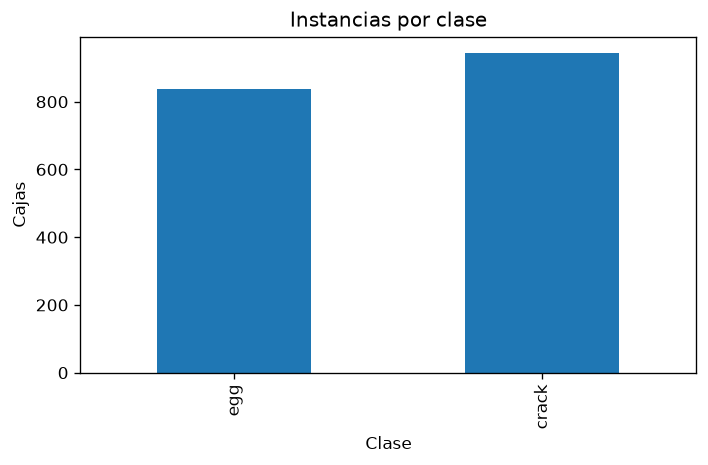

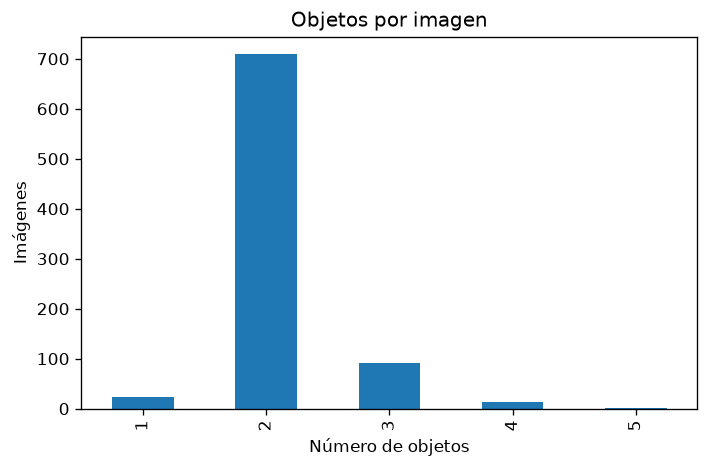

In [16]:
display(Image(EDA / "class_distribution.png"))
display(Image(EDA / "objects_per_image.png"))

## 4. Resoluciones

,width,height,split,n
0,3456,4608,test,100
1,3456,4608,train,739
2,4608,3456,train,1


portrait: 839 landscape: 1


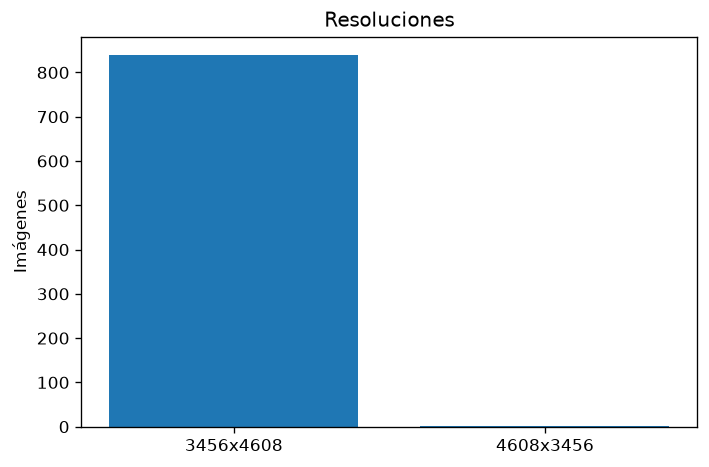

In [17]:
imagenes = imagenes.assign(aspect=imagenes["width"] / imagenes["height"])
res = (
    imagenes.groupby(["width", "height", "split"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
display(res)
print("portrait:", int((imagenes.height > imagenes.width).sum()),
      "landscape:", int((imagenes.width > imagenes.height).sum()))
display(Image(EDA / "resolution_distribution.png"))

839 fotos son **3456×4608** (retrato, aspect 0,75). Una sola es **4608×3456** (apaisada), en train.
Para YOLOv8n (`imgsz` 640) esto implica un *downsample* fuerte: las grietas finas pueden perderse si no se recorta o no se sube el tamaño de entrada.

## 5. Bounding boxes

clase                  crack           egg
bbox_w   count  9.450000e+02  8.380000e+02
         mean   6.432561e+02  2.152822e+03
         std    4.444634e+02  1.699431e+02
         min    3.100000e+01  1.408000e+03
         25%    2.850000e+02  2.044250e+03
         50%    5.550000e+02  2.108000e+03
         75%    9.060000e+02  2.255000e+03
         max    2.322000e+03  2.761000e+03
bbox_h   count  9.450000e+02  8.380000e+02
         mean   5.724571e+02  1.718332e+03
         std    3.558108e+02  1.573706e+02
         min    3.900000e+01  1.432000e+03
         25%    2.940000e+02  1.621000e+03
         50%    5.000000e+02  1.689000e+03
         75%    8.050000e+02  1.771000e+03
         max    1.746000e+03  2.640000e+03
area     count  9.450000e+02  8.380000e+02
         mean   4.408254e+05  3.713153e+06
         std    4.861214e+05  5.743974e+05
         min    4.805000e+03  2.566144e+06
         25%    7.886400e+04  3.331068e+06
         50%    2.337840e+05  3.554177e+06
         75%    6.544650e+05  3.946912e+06
         max    3.991356e+06  6.137256e+06
area_rel count  9.450000e+02  8.380000e+02
         mean   2.768091e-02  2.331614e-01
         std    3.052520e-02  3.606835e-02
         min    3.017221e-04  1.611368e-01
         25%    4.952136e-03  2.091690e-01
         50%    1.468009e-02  2.231788e-01
         75%    4.109606e-02  2.478399e-01
         max    2.506307e-01  3.853790e-01
aspect   count  9.450000e+02  8.380000e+02
         mean   1.480337e+00  1.257506e+00
         std    1.315215e+00  8.522142e-02
         min    1.151515e-01  7.371728e-01
         25%    6.053640e-01  1.248837e+00
         50%    1.132020e+00  1.267480e+00
         75%    1.826531e+00  1.293528e+00
         max    1.104615e+01  1.354942e+00
cx_rel   count  9.450000e+02  8.380000e+02
         mean   4.592000e-01  4.638496e-01
         std    1.054661e-01  6.515029e-02
         min    3.993056e-02  2.579572e-01
         25%    3.936632e-01  4.211516e-01
         50%    4.583333e-01  4.627459e-01
         75%    5.296586e-01  5.078487e-01
         max    7.745949e-01  6.911169e-01
cy_rel   count  9.450000e+02  8.380000e+02
         mean   5.013650e-01  4.987428e-01
         std    8.712619e-02  5.683031e-02
         min    1.305339e-01  2.592231e-01
         25%    4.432509e-01  4.906684e-01
         50%    5.018446e-01  4.940321e-01
         75%    5.602214e-01  4.985894e-01
         max    7.827691e-01  7.189670e-01

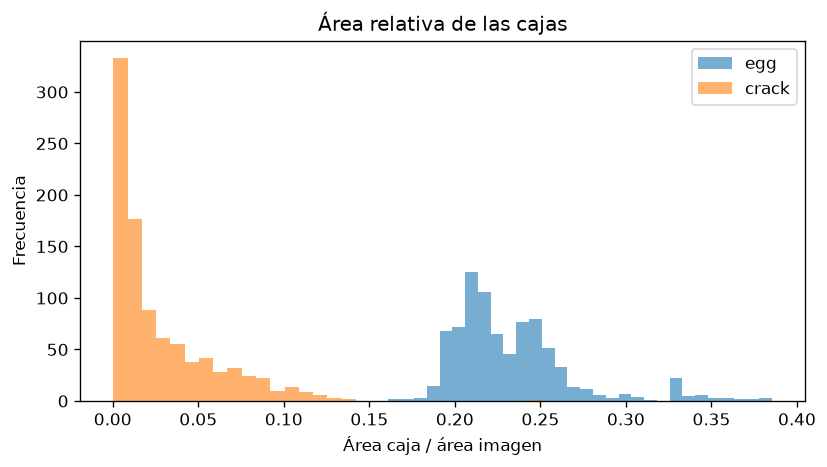

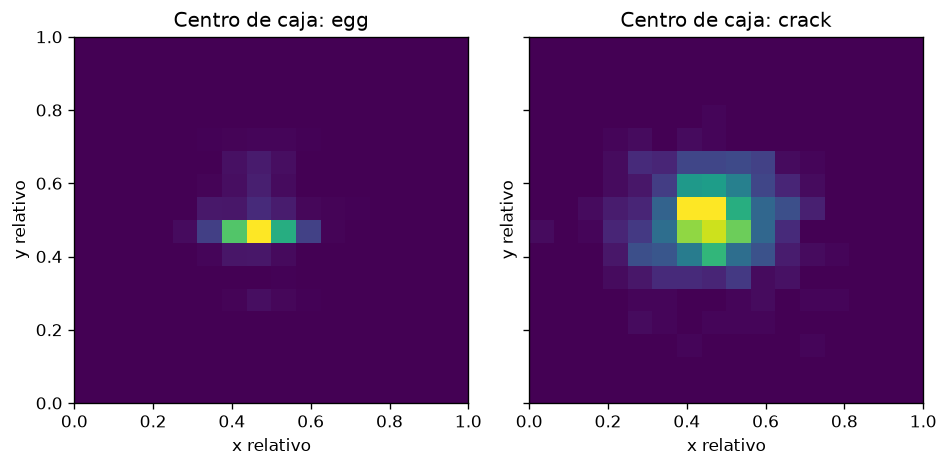

In [18]:
cols = ["bbox_w", "bbox_h", "area", "area_rel", "aspect", "cx_rel", "cy_rel"]
display(cajas.groupby("clase")[cols].describe().T)
display(Image(EDA / "bbox_area_distribution.png"))
display(Image(EDA / "bbox_center_heatmap.png"))

| Clase | Área relativa media / mediana | Ancho medio (px) | Alto medio (px) | Cajas < 0,1 % del frame |
| --- | --- | --- | --- | --- |
| egg | 0,233 / 0,223 | 2153 | 1718 | 0 |
| crack | 0,028 / 0,015 | 643 | 572 | 27 |

`egg` ocupa ~22 % del fotograma: caja grande, fácil para un detector.
`crack` es un orden de magnitud más pequeña (mediana ~1,5 % del área). 372 grietas tienen área relativa < 1 %; 239 < 0,5 %.

Los centros de `egg` se agrupan hacia el medio del cuadro. `crack` también, porque la grieta está sobre el huevo.

## 6. Calidad de anotaciones

In [19]:
ious = solapes(cajas)
cruz = ious[ious["clase_a"] != ious["clase_b"]]
calidad = pd.Series(
    {
        "cajas_fuera_de_imagen": int(cajas["fuera"].sum()),
        "ancho_o_alto_<=0": int(cajas["degenerada"].sum()),
        f"area_rel_<{AREA_REL_MUY_PEQ}": int((cajas["area_rel"] < AREA_REL_MUY_PEQ).sum()),
        f"area_rel_>{AREA_REL_MUY_GRANDE}": int((cajas["area_rel"] > AREA_REL_MUY_GRANDE).sum()),
        "imagenes_sin_objetos": int((imagenes["n_objetos"] == 0).sum()),
        "xml_invalidos": len(meta["xml_invalidos"]),
        "pares_egg_crack": int(len(cruz)),
        "iou_media_egg_crack": float(cruz["iou"].mean()) if len(cruz) else None,
        "iou_mediana_egg_crack": float(cruz["iou"].median()) if len(cruz) else None,
        "iou_>0.1": int((cruz["iou"] > 0.1).sum()) if len(cruz) else 0,
    }
)
display(calidad.to_frame("valor"))

,valor
cajas_fuera_de_imagen,0.000000
ancho_o_alto_<=0,0.000000
area_rel_<0.001,27.000000
area_rel_>0.8,0.000000
imagenes_sin_objetos,0.000000
xml_invalidos,0.000000
pares_egg_crack,941.000000
iou_media_egg_crack,0.122426
iou_mediana_egg_crack,0.061651
iou_>0.1,362.000000


Integridad de emparejamiento: **0** JPEG sin XML, **0** XML sin JPEG, **0** XML rotos, **0** cajas fuera o degeneradas, **0** imágenes vacías, **0** cajas que cubran >80 % del frame.

Las 27 cajas «extremadamente pequeñas» (área relativa < 0,001) son todas `crack`.

IoU medio egg–crack ≈ 0,12 (mediana 0,06). Es esperable: la grieta está **dentro** del huevo. No indica error de anotación; sí indica que un detector de dos clases en la misma imagen verá cajas anidadas.

## 7. Ejemplos (seed 42)

Rojo = `egg`. Azul = `crack`. Miniaturas; las fotos originales son 3456×4608.

**samples_solo_egg.png**

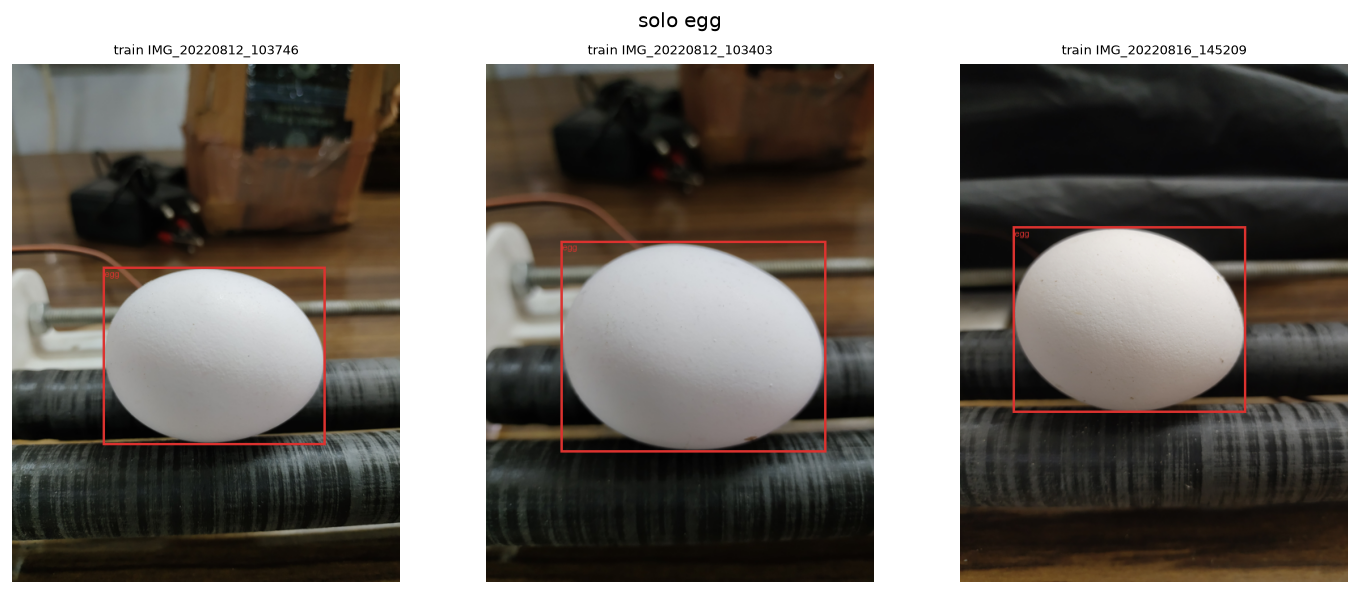

**samples_solo_crack.png**

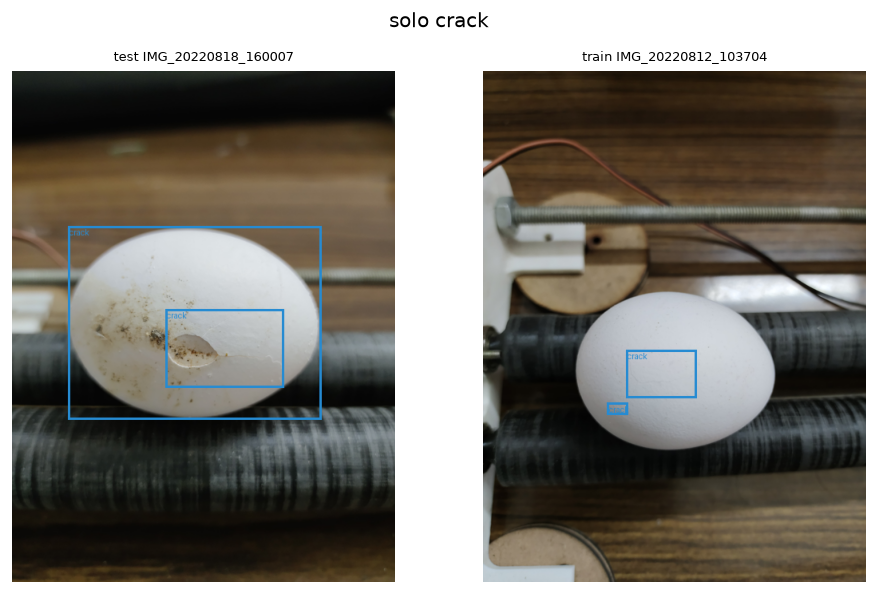

**samples_ambas_clases.png**

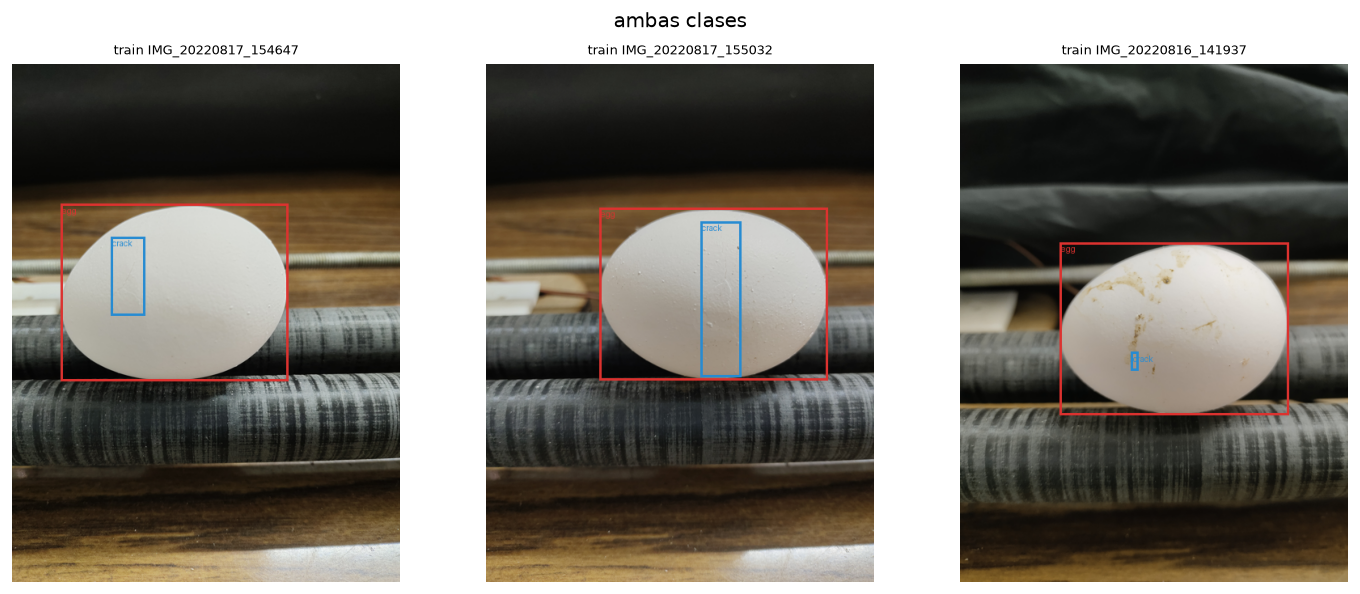

**samples_muchos_objetos.png**

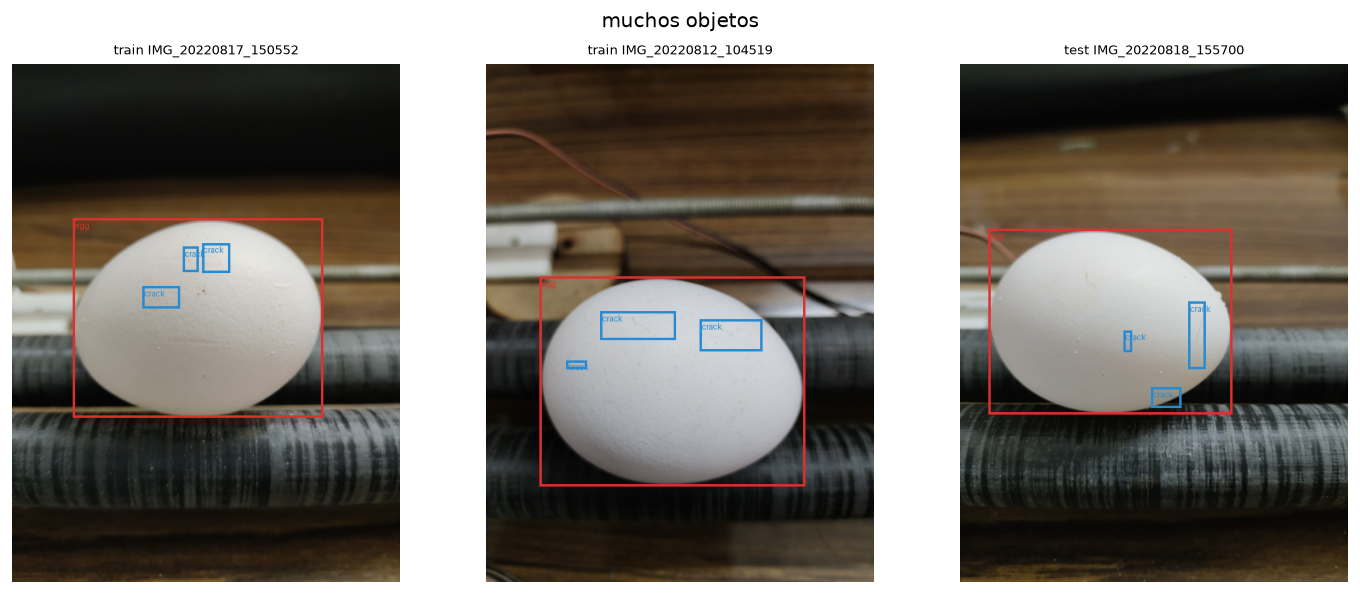

**samples_cajas_pequenas.png**

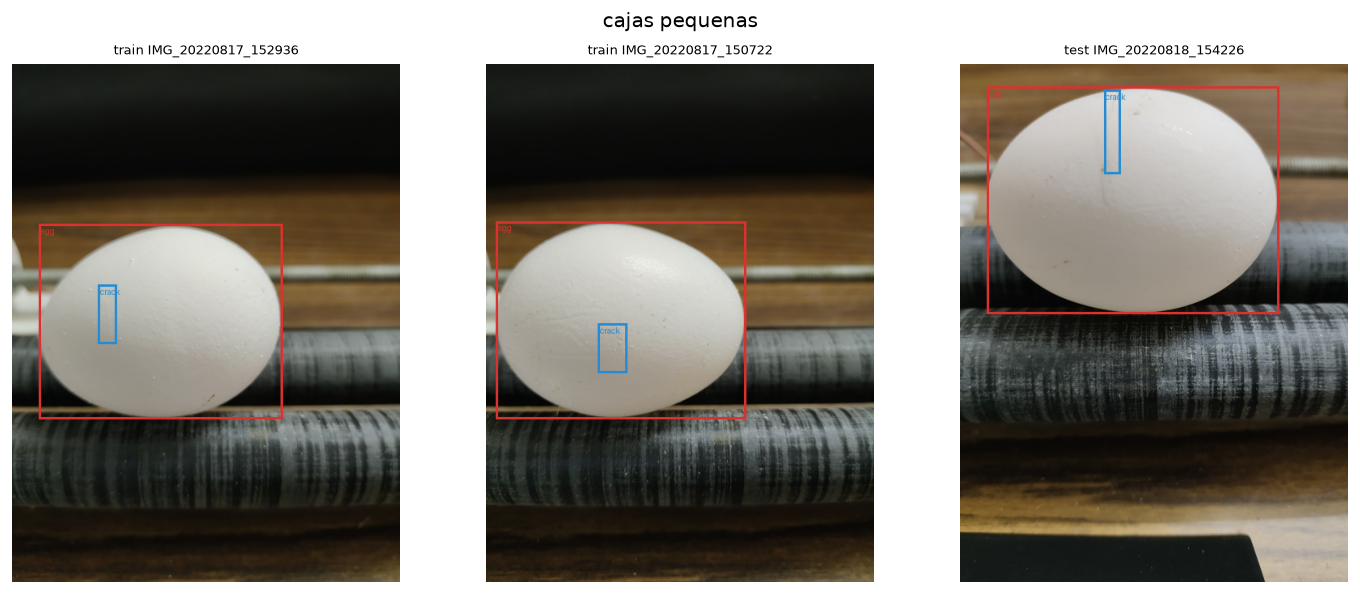

In [20]:
for nombre in [
    "samples_solo_egg.png",
    "samples_solo_crack.png",
    "samples_ambas_clases.png",
    "samples_muchos_objetos.png",
    "samples_cajas_pequenas.png",
]:
    ruta = EDA / nombre
    if ruta.exists():
        display(Markdown(f"**{nombre}**"))
        display(Image(ruta))

Las muestras muestran un patrón de captura muy repetido: huevo claro sobre mesa oscura, a menudo con una barra metálica. La grieta es una caja chica sobre la cáscara. El fondo no es una banda transportadora ni la cámara del iPhone del MVP.

## 8. Train vs test

,imagenes,objetos_media,pct_egg,pct_crack
split,,,,
test,100,2.060000,99.000000,100.000000
train,740,2.131081,99.864865,96.891892


clase,crack,egg
split,,
test,107,99
train,838,739


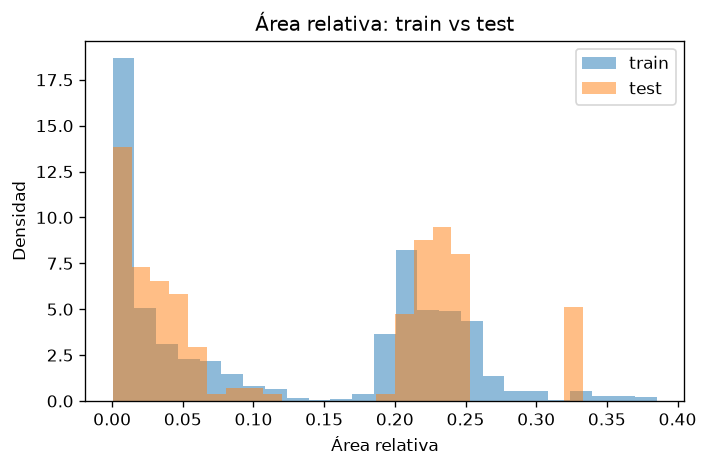

In [21]:
cmp = imagenes.groupby("split").agg(
    imagenes=("stem", "size"),
    objetos_media=("n_objetos", "mean"),
    pct_egg=("tiene_egg", "mean"),
    pct_crack=("tiene_crack", "mean"),
)
cmp["pct_egg"] *= 100
cmp["pct_crack"] *= 100
display(cmp)
display(cajas.groupby(["split", "clase"]).size().unstack())
display(Image(EDA / "bbox_area_train_vs_test.png"))

| | Train | Test |
| --- | --- | --- |
| Imágenes | 740 | 100 |
| Objetos | 1577 | 206 |
| Objetos/imagen | 2,13 | 2,06 |
| % con egg | 99,86 | 99,00 |
| % con crack | 96,89 | 100,00 |
| Área relativa media de caja | 0,123 | 0,133 |
| Resolución | 739× 3456×4608 + 1 apaisada | 100× 3456×4608 |

Test **sí parece representativo** del mismo protocolo de captura. No hay `validation` original.

## 9. Hallazgos del EDA

- **¿Balanceado?** En recuento de cajas, sí (47 % egg / 53 % crack). En composición por imagen, no: 815/840 tienen las dos clases y solo 2 son únicamente `crack`.
- **¿Cajas suficientemente grandes?** `egg` sí (~22 % del frame). `crack` no de forma uniforme: mediana 1,5 % del área; 27 cajas < 0,1 %; cientos por debajo del 1 %. Eso es el riesgo principal para YOLOv8n a 640 px.
- **¿Train vs test?** Misma resolución, mismas clases, objetos/imagen y tamaños de caja muy parecidos. Test es un 11,9 % del total y cubre grieta en el 100 % de sus fotos.
- **¿Clases poco representadas?** Ninguna de las dos desaparece. El caso raro es «solo crack» (2 imágenes).
- **¿Sesgo de fondo/iluminación?** Sí, de dominio: fondo oscuro de mesa, huevo centrado, iluminación de estudio. Brillo medio de una muestra de 80 miniaturas ≈ 73/255 (desv. 8,7): poca variedad lumínica. No es el escenario Expo Go / banda del MVP.
- **¿Problemas para YOLOv8?** (1) VOC hay que convertirlo después, no ahora. (2) Grieta pequeña + imagen 12 MP. (3) Cajas anidadas egg⊃crack. (4) Sidecars `__MACOSX` si alguien lista `.jpg` a ciegas.
- **¿Augmentation?** Recomendable más adelante (mosaic, escala, brillo) sobre todo para `crack`. No se aplica en este paso.
- **¿Validation split?** Sí hará falta uno propio: el origen solo trae train/test. No se crea aquí.

**Siguiente paso técnico:** convertir VOC→YOLO **después** de este EDA, excluyendo `__MACOSX`, y reservar un `val` a partir de train. **No entrenar todavía.**